# Peak Tracking (Single File)

This notebook loads a single GIWAXS NetCDF file, tracks peak evolution over time, and visualizes normalized integrated intensities.

**Workflow:**
1. Prepare NetCDF data with the CLI (see next cell).
2. Load one .nc file and normalize intensity.
3. Configure peaks and run peak tracking.
4. Plot normalized peak evolution.

**Tip:** Run cells from top to bottom to ensure all variables are initialized.

## Data preparation (CLI)

Use the CLI to convert raw GIWAXS frames into a NetCDF file (.nc) before running this notebook.

Example (PowerShell):
- From the repo root: uv run giwaxs_cli.py --save_csv <experiment_folder>
- The experiment folder should contain the .tif frames (and a .poni file in its parent or the folder itself).

Example path:
- G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\yiru_insitu_Dec2025\insitu_0p5M_MeOMBAI_7

Output:
- A NetCDF file will be written next to the experiment folder (or to --output_dir if provided).
- Use that .nc path in the next cell (da_file).

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import re
from analysis import process_time_series_by_peak


## Load a single NetCDF file

Update da_file to the .nc file produced by the CLI. The file should contain a 2D array of intensity vs time and q.

In [2]:
da_file = Path(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\processed_v1\0p1M_ClMBAI_1.nc")

da = xr.open_dataarray(da_file)

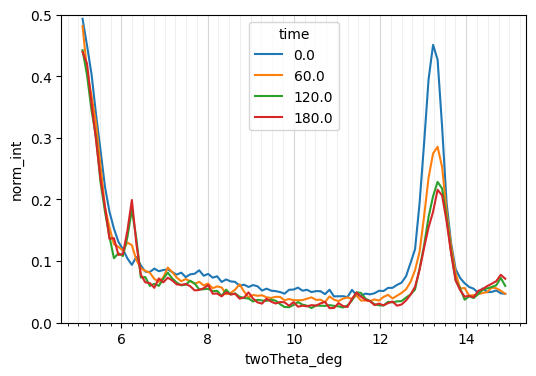

In [3]:
ds = da.to_dataset(name="intensity")

ds['norm_int'] = (ds['intensity'] - ds['intensity'].min()) / (ds['intensity'].max() - ds['intensity'].min())

twoTheta = np.rad2deg(2 * np.arcsin(ds["q_A^-1"] * 1.54 / (4 * np.pi))).values
ds = ds.assign_coords({"twoTheta_deg": ("q_A^-1", twoTheta)}).swap_dims({"q_A^-1": "twoTheta_deg"})

fig, ax = plt.subplots(figsize=(6,4))
ds['norm_int']\
    .shift(twoTheta_deg=0)\
    .sel(time=[0, 60, 120, 180], method='nearest')\
    .sel(twoTheta_deg=slice(5., 15))\
    .plot.line(x="twoTheta_deg", ax=ax)

ax.set_ylim(None, 0.5)
# use minor ticks for x-axis
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.5)
ax.grid(True, which='minor', axis='x', linestyle='-', alpha=0.2)


c:\Users\yrliu98\Documents\als-xrd-12-3-2\analysis.py:139: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(voigt_profile_func, x_data, y_data, p0=initial_guess, bounds=bounds)


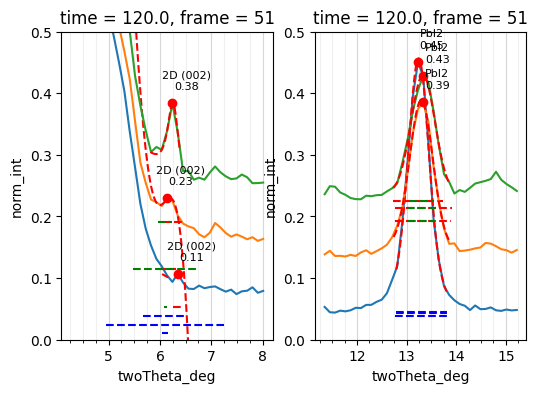

In [4]:
from analysis import baseline_correction, find_peaks_in_window, voigt_fit, voigt_profile_func
import numpy as np
from scipy.signal import peak_widths
from vogit_width import voigt_width_at_height

peaks_of_interest_with_phase = {
    "MBAI": [
        (6.9, 2, (-1, 0), "2D (002)"), 
        (13.3, 2, (0, -1), "PbI2")
    ],
    "ClMBAI": [
        (6.1, 2, (-1, 0), "2D (002)"), 
        (13.3, 2, (0, -1), "PbI2")
    ],
    "p?MeOMBAI": [
        (6.1, 0.8, (-1, 0), "2D (002)"),  # Backward: Start at End (-1) -> Go to Start (0). Window Increased.
        (13.3, 2.0, (0, -1), "PbI2"),     
        (7.0, 0.8, (-1, 0), "MeOMBAI")
    ]
}

peaks = peaks_of_interest_with_phase["ClMBAI"]

fig, axes = plt.subplots(1, len(peaks), figsize=(6,4))

axes = axes.flatten() if len(peaks) > 1 else [axes]

times = [0, 60, 120]

for i, (cen, width, phase, label) in enumerate(peaks):
    
    ds_partial = ds['norm_int'].sel(twoTheta_deg=slice(cen-width, cen+width)).sel(time=times, method='nearest')
    
    

    for j, t in enumerate(ds_partial.time.values):
        da_t = ds_partial.sel(time=t)
        da_t = da_t + 0.1*j
        da_t.plot.line(x="twoTheta_deg", ax=axes[i])
        peaks_x, intensities, props = find_peaks_in_window(da_t, x="twoTheta_deg", target=cen, window_size=width)
        # Only consider the most prominent peak
        peak_x = peaks_x[np.argmax(intensities)]
        intensity = np.max(intensities)
        props = props[np.argmax(intensities)]

        # convert peak_x to index for width calculation
        # peak_idx = np.where(da_t.twoTheta_deg.values == peak_x)[0][0]

        # half_width = peak_widths(da_t.values, [peak_idx], rel_height=0.5)[0]

        # # convert half_width from index to twoTheta units
        # half_width = half_width * (da_t.twoTheta_deg.values[1] - da_t.twoTheta_deg.values[0])
        half_width = props['half_widths']
        # plot the peak position and half-width
        axes[i].plot(peak_x, intensity, 'ro')  # Peak position
        axes[i].hlines(intensity * 0.5, peak_x - half_width, peak_x + half_width, color='r', linestyle='--')  # Half-width

        # Only annotate if the peak is within the specified window
        if cen - width <= peak_x <= cen + width:
            axes[i].annotate(f"{label}\n{intensity:.2f}", xy=(peak_x, intensity), 
                             xytext=(10, 10), textcoords='offset points', ha='center', fontsize=8)
            
        # fit the peak with a Voigt profile and plot the fit
        _, popt = voigt_fit(
                            da_t, x="twoTheta_deg", 
                            initial_guess=peak_x, 
                            window_size=max(0.5, half_width * 3), 
                            no_slope=False
                        )
        
        fwhm = voigt_width_at_height(popt[2], popt[3], 0.5)
        fw10m = voigt_width_at_height(popt[2], popt[3], 0.1)
        
        fit_x = np.linspace(cen - 1 * fwhm, cen + 1 * fwhm, 100)
        axes[i].plot(fit_x, voigt_profile_func(fit_x, *popt), 'r--', label='Fit')
        # plot the FWHM and FW10M as horizontal lines
        axes[i].hlines(intensity * 0.5, cen - fwhm/2, cen + fwhm/2, color='g', linestyle='--', label='FWHM')
        axes[i].hlines(intensity * 0.1, cen - fw10m/2, cen + fw10m/2, color='b', linestyle='--', label='FW10M')
        # axes[i].legend()

        

            
        


for ax in axes:
    ax.set_ylim(0, 0.5)
    # use minor ticks for x-axis
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
    ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.5)
    ax.grid(True, which='minor', axis='x', linestyle='-', alpha=0.2)

In [5]:
result_dfs = {}

## Configure peak tracking

Define peak positions (2θ in degrees), search windows, and tracking direction. The peaks_of_interest_with_phase mapping is selected based on the experiment name. Adjust global_shift_corrections if needed.

**About `result_dfs = {}` (cell above):**
- This dictionary stores the peak-tracking DataFrames for each experiment name.
- If you re-run the analysis cell without re-running `result_dfs = {}`, previous results remain and will still be plotted.
- To clear previous runs, re-run `result_dfs = {}` (or restart the kernel).

In [6]:
# --- Configuration ---
# Format: (Center, Window, (Start_Index, Stop_Index), Name)
# Start_Index: Where to start tracking
# Stop_Index: Where to end tracking (Inclusive). 
# Direction is implied: (0, -1) = Forward, (-1, 0) = Backward.

peaks_of_interest_with_phase = {
    "MBAI": [
        (6.9, 2, (-1, 0), "2D (002)"), 
        (13.3, 2, (0, -1), "PbI2")
    ],
    "ClMBAI": [
        (6.1, 2, (-1, 25), "2D (002)"), 
        (13.3, 2, (0, -1), "PbI2")
    ],
    "p?MeOMBAI": [
        (6.1, 0.8, (-1, 0), "2D (002)"),  # Backward: Start at End (-1) -> Go to Start (0). Window Increased.
        (13.3, 2.0, (0, -1), "PbI2"),     
        (7.0, 0.8, (-1, 0), "MeOMBAI")
    ]
}

global_shift_corrections = {
    "1p5M_pMeOMBAI_1": -5,
    "insitu_0p5M_MeOMBAI_7": 3,
    "insitu_1p0M_MeOMBAI_6": 3
}


output_base_dir = da_file.parent / "peak_tracking_results"

exp_name = da_file.stem

print(f"\n=== Processing Experiment: {exp_name} ===")

# 1. Select and Shift Data
time_series_da = ds["norm_int"].sel(twoTheta_deg=slice(5.5, 20)).dropna(dim="time")

shift = global_shift_corrections.get(exp_name, 0)
if shift != 0:
    time_series_da = time_series_da.shift(twoTheta_deg=shift)

# 2. Get Peaks Definition
current_peaks_def = []
for key, val in peaks_of_interest_with_phase.items():
    if re.search(f"M_{key}", exp_name, re.IGNORECASE):
        current_peaks_def = val
        break


# 3. Run Peak Tracking
df_evolution = process_time_series_by_peak(
    time_series_da,
    peaks_definition=current_peaks_def,
    sample_name=exp_name,
    output_dir=output_base_dir,
    debug=True 
    # Add baseline_kwargs if correction is needed, e.g., method='asls', lam=5e3
)

if not df_evolution.empty:
    result_dfs[exp_name] = df_evolution
    print("\n--- Evolution DataFrame Head ---")
    print(df_evolution.head())
else:
    print("  No effective peak data found.")


=== Processing Experiment: 0p1M_ClMBAI_1 ===


c:\Users\yrliu98\Documents\als-xrd-12-3-2\analysis.py:139: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(voigt_profile_func, x_data, y_data, p0=initial_guess, bounds=bounds)
c:\Users\yrliu98\Documents\als-xrd-12-3-2\analysis.py:139: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(voigt_profile_func, x_data, y_data, p0=initial_guess, bounds=bounds)
c:\Users\yrliu98\Documents\als-xrd-12-3-2\analysis.py:139: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(voigt_profile_func, x_data, y_data, p0=initial_guess, bounds=bounds)
c:\Users\yrliu98\Documents\als-xrd-12-3-2\analysis.py:139: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(voigt_profile_func, x_data, y_data, p0=initial_guess, bounds=bounds)
c:\Users\yrliu98\Documents\als-xrd-12-3-2\analysis.py:139: OptimizeWarning: Covariance of the parameters could n


--- Evolution DataFrame Head ---
PeakName  2D (002)      PbI2
Time                        
0.0            NaN  0.238207
2.0            NaN  0.233971
4.0            NaN  0.233837
6.0            NaN  0.210160
8.0            NaN  0.204612


## Visualize peak evolution

The plot below normalizes each peak trace per experiment and shows a smoothed trend for easier comparison across time.

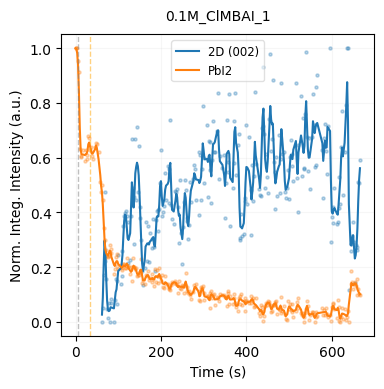

In [7]:
import matplotlib.pyplot as plt
import re
import numpy as np
from scipy.ndimage import gaussian_filter1d

merged_dfs = result_dfs

# Create a single merged DataFrame for global inspection
final_merged_df = pd.concat(merged_dfs, axis=1)
final_merged_df.columns.names = ['experiment', 'phase']


# Cell 14: Visualization of Peak Evolution
# -------------------------------------------------------------------------

# Plot all experiments in a grid (4 columns, N rows)
all_experiments = sorted(merged_dfs.keys())
num_exps = len(all_experiments)
if num_exps == 0:
    print("No experiments to plot. Run the analysis cell first.")
else:
    ncols = 3
    nrows = int(np.ceil(num_exps / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(max(6, ncols * 3.5), max(4, nrows * 3.2)), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    # Plot each experiment
    for i, exp_name in enumerate(all_experiments):
        ax = axes[i]
        df = merged_dfs[exp_name]
        
        # Plot each phase found in the dataframe
        for column in df.columns:
            # Get data and drop NaNs (some peaks might not be found in all frames)
            series = df[column].dropna()
            if series.empty:
                continue

            # Filtering and Normalization
            # Remove extreme outliers for better plotting scale
            lower_bound = np.percentile(series, 1)
            upper_bound = np.percentile(series, 99)
            clipped = series.clip(lower_bound, upper_bound)
            
            # Min-Max Normalize
            denom = (clipped.max() - clipped.min())
            if denom == 0:
                denom = 1
            norm_data = (clipped - clipped.min()) / denom
            
            ax.scatter(norm_data.index, norm_data, alpha=0.3, s=5)
            
            # Smoothing
            # Sigma=1 roughly smooths over +/- 1 second if data is 1s resolution
            smooth_data = gaussian_filter1d(norm_data, sigma=1)
            ax.plot(norm_data.index, smooth_data, linewidth=1.5, label=column)
        
        # Formatting
        clean_title = exp_name.replace("p", ".", 1).replace("insitu_", "")
        ax.set_title(clean_title, y=1.02, fontsize=10)
        ax.set_xlabel("Time (s)")
        
        if i % ncols == 0:
            ax.set_ylabel("Norm. Integ. Intensity (a.u.)")
        
        # Markers for experiment events
        ax.axvline(5, color='gray', linestyle='--', alpha=0.5, linewidth=1) # Dispense
        ax.axvline(35, color='orange', linestyle='--', alpha=0.5, linewidth=1) # Heating
        
        ax.legend(fontsize='small', framealpha=0.6)
        ax.grid(True, alpha=0.1)

    # Hide any unused axes
    for j in range(num_exps, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()